# 02 — Wearable wrist PPG during walking: Wrist-PPG-Exercise s1_walk

**Goal.** Validate Lamina's PPG cleaning + systolic-peak detection
(`ppg-clean`, `ppg-peaks` bridge ops) on a *wearable, in-motion* wrist PPG
signal, and quantify heart-rate accuracy against the dataset's chest-ECG beat
annotations.

**Dataset.** [Wrist PPG During Exercise](https://physionet.org/content/wrist-ppg-during-exercise/)
(Jarchi & Casson, EMBC 2017; ODC-BY 1.0). Record `s1_walk`: subject s1,
walking activity; wrist PPG @ 256 Hz (header rate; non-ECG channels were
resampled to 256 Hz by the dataset authors) + chest ECG with expert `.atr`
beat annotations.

**Honesty note.** This is a *hard* record for any PPG algorithm: wrist PPG
during walking is heavily contaminated by motion artifact. The Stage-2 PPG
validation (see `validation/results/ppg/NOTES.md`) measured a walk-activity
HR MAE of **≈16 bpm** across walk records; `s1_walk` is the *worst* walk
record (per-record HR bias +33.0 bpm in `metrics_extra.csv`). This notebook
reproduces that finding openly rather than hiding it, and shows that the
chest-ECG channel of this same record is also hard for Lamina. The HR
reference is annotation-derived (independent of Lamina).

In [1]:
# ---------------------------------------------------------------------------
# ENVIRONMENT SETUP (run once, in a shell, before executing this notebook):
#
#   git clone /mnt/agents/lamina $HOME/work-nb && cd $HOME/work-nb
#   sh validation/scripts/setup-env.sh $HOME/work-nb     # Rust + Python deps + builds lamina_bridge
#   pip install jupyter nbconvert nbformat               # notebook tooling
#
# DATA FETCH (cached under $HOME/data, never committed to the repo):
#
#   python -c "import wfdb; wfdb.dl_database('wrist', \
#       dl_dir='$HOME/data/wrist', records=['s1_walk'])"
#   # (wfdb downloads physionet.org/files/wrist/1.0.0/s1_walk.{hea,dat,atr})
#
# Execute:  jupyter nbconvert --execute --inplace 02_wearable_ppg_wrist.ipynb
# ---------------------------------------------------------------------------

In [2]:
import os
import sys
from pathlib import Path

# Locate the repository root (directory containing validation/SPEC.md) and put
# it on sys.path so `import validation...` resolves regardless of the notebook
# kernel's working directory.
REPO_ROOT = None
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "validation" / "SPEC.md").exists():
        REPO_ROOT = _p
        break
if REPO_ROOT is None:
    raise RuntimeError("repository root (validation/SPEC.md) not found; "
                       "run this notebook from inside the lamina checkout")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_ROOT = Path(os.environ.get("LAMINA_NB_DATA", Path.home() / "data"))
print(f"repo root: {REPO_ROOT}")
print(f"data cache: {DATA_ROOT}")

import numpy as np
import matplotlib.pyplot as plt

from validation.bridge import LaminaBridge
from validation.metrics import rate_metrics
from validation.datasets.ppg import _interp_nans, _windowed_hr_from_peaks

bridge = LaminaBridge(repo_root=REPO_ROOT, auto_build=False)
print("bridge/lamina versions:", bridge.version())

repo root: /home/kimi/work-nb
data cache: /home/kimi/data


bridge/lamina versions: {'bridge_version': '0.1.0', 'lamina_version': '0.1.0'}


## 1. Load `s1_walk`

The wrist PPG channel contains short NaN gaps (wrist-device dropouts); the
bridge rejects non-finite input (fail-fast), so gaps are linearly interpolated
exactly as the Stage-2 adapter does (`validation.datasets.ppg._interp_nans`),
with the interpolated count reported.

In [3]:
import wfdb

rec_dir = DATA_ROOT / "wrist"
if not (rec_dir / "s1_walk.dat").exists():
    rec_dir.mkdir(parents=True, exist_ok=True)
    wfdb.dl_database("wrist", dl_dir=str(rec_dir), records=["s1_walk"])

record = wfdb.rdrecord(str(rec_dir / "s1_walk"))
fs = float(record.fs)
names = list(record.sig_name)
ppg_raw = np.asarray(record.p_signal[:, names.index("wrist_ppg")], dtype=float)
acc = np.column_stack([_interp_nans(record.p_signal[:, names.index(
    f"wrist_low_noise_accelerometer_{a}")].astype(float))[0] for a in "xyz"])
ppg, n_interp = _interp_nans(ppg_raw)

ann = wfdb.rdann(str(rec_dir / "s1_walk"), "atr")
beats = np.sort(np.asarray(ann.sample, dtype=np.int64))  # chest-ECG 'N' beats

dur = len(ppg) / fs
print(f"s1_walk: {len(ppg)} samples @ {fs:.0f} Hz = {dur/60:.1f} min; "
      f"{n_interp} NaN samples interpolated ({100*n_interp/len(ppg):.2f}%)")
print(f"chest-ECG beat annotations: {len(beats)} "
      f"(mean HR ≈ {60*len(beats)/dur:.0f} bpm)")

s1_walk: 150529 samples @ 256 Hz = 9.8 min; 234 NaN samples interpolated (0.16%)
chest-ECG beat annotations: 563 (mean HR ≈ 57 bpm)


## 2. Lamina `ppg-clean` + `ppg-peaks`

Note the raw signal: amplitude swings of an order of magnitude within seconds
— that is motion artifact, not physiology.

Lamina ppg-peaks: 828 peaks (raw peak rate ≈ 84/min)


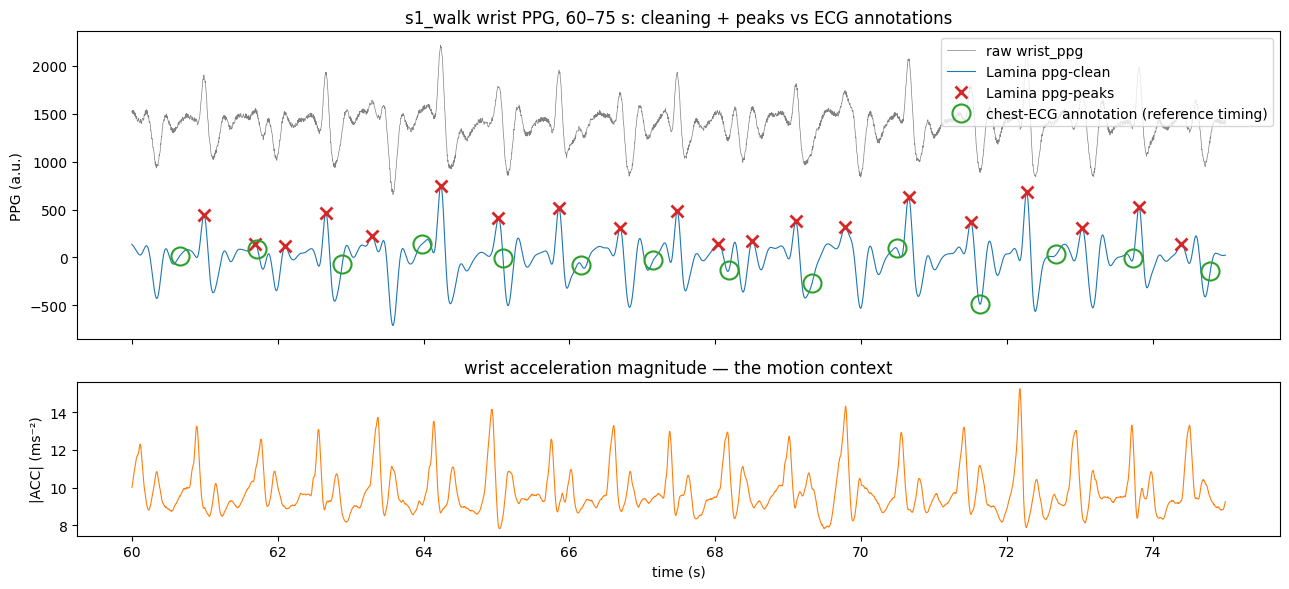

In [4]:
cleaned = bridge.ppg_clean(ppg, fs)
res = bridge.ppg_peaks(ppg, fs)
ppg_peaks = np.asarray(res["peaks"], dtype=np.int64)
print(f"Lamina ppg-peaks: {res['count']} peaks "
      f"(raw peak rate ≈ {60*res['count']/dur:.0f}/min)")

t0, t1 = 60.0, 75.0
i0, i1 = int(t0*fs), int(t1*fs)
t = np.arange(i0, i1) / fs
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
ax[0].plot(t, ppg[i0:i1], lw=0.5, color="0.5", label="raw wrist_ppg")
ax[0].plot(t, cleaned[i0:i1], lw=0.8, color="tab:blue", label="Lamina ppg-clean")
pk = ppg_peaks[(ppg_peaks >= i0) & (ppg_peaks < i1)]
ax[0].plot(pk/fs, cleaned[pk], "x", color="tab:red", ms=9, mew=2, label="Lamina ppg-peaks")
bt = beats[(beats >= i0) & (beats < i1)]
ax[0].plot(bt/fs, cleaned[bt], "o", mfc="none", color="tab:green", ms=13, mew=1.5,
           label="chest-ECG annotation (reference timing)")
ax[0].legend(loc="upper right"); ax[0].set_ylabel("PPG (a.u.)")
ax[0].set_title("s1_walk wrist PPG, 60–75 s: cleaning + peaks vs ECG annotations")
acc_mag = np.sqrt((acc**2).sum(axis=1))
ax[1].plot(t, acc_mag[i0:i1], lw=0.8, color="tab:orange")
ax[1].set_ylabel("|ACC| (ms⁻²)"); ax[1].set_xlabel("time (s)")
ax[1].set_title("wrist acceleration magnitude — the motion context")
plt.tight_layout(); plt.show()

## 3. Heart-rate series: Lamina PPG vs chest-ECG annotations

Standard protocol for this dataset: 8 s windows, 2 s step; HR = mean(60/IBI)
over IBIs whose midpoint falls in the window
(`validation.datasets.ppg._windowed_hr_from_peaks` — identical function for
reference and estimate).

windows compared: 291 / 291 (100% coverage)
HR MAE  = 33.0 bpm
HR bias = +33.0 bpm  (Lamina PPG minus annotation)
HR RMSE = 34.7 bpm,  Pearson r = 0.05


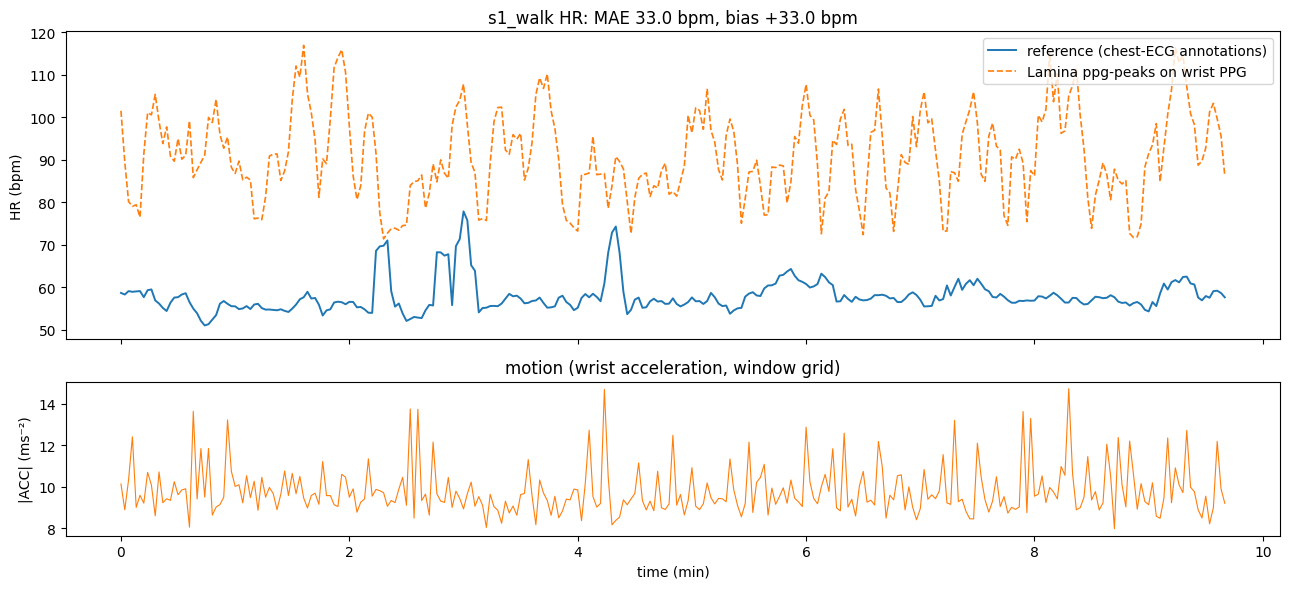

In [5]:
n = len(ppg)
t_win, hr_ref = _windowed_hr_from_peaks(beats, fs, n, 8.0, 2.0)
_, hr_est = _windowed_hr_from_peaks(ppg_peaks, fs, n, 8.0, 2.0)

ok = np.isfinite(hr_ref) & np.isfinite(hr_est)
rm = rate_metrics(hr_ref[ok], hr_est[ok])
print(f"windows compared: {ok.sum()} / {len(t_win)} "
      f"({100*ok.mean():.0f}% coverage)")
print(f"HR MAE  = {rm['mae']:.1f} bpm")
print(f"HR bias = {rm['bias']:+.1f} bpm  (Lamina PPG minus annotation)")
print(f"HR RMSE = {rm['rmse']:.1f} bpm,  Pearson r = {rm['pearson_r']:.2f}")

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
ax[0].plot(t_win[ok]/60, hr_ref[ok], lw=1.4, label="reference (chest-ECG annotations)")
ax[0].plot(t_win[ok]/60, hr_est[ok], lw=1.2, ls="--",
           label="Lamina ppg-peaks on wrist PPG")
ax[0].set_ylabel("HR (bpm)"); ax[0].legend(loc="upper right")
ax[0].set_title(f"s1_walk HR: MAE {rm['mae']:.1f} bpm, bias {rm['bias']:+.1f} bpm")
ax[1].plot(t_win/60, acc_mag[::int(2*fs)][:len(t_win)], lw=0.8,
           color="tab:orange")
ax[1].set_ylabel("|ACC| (ms⁻²)"); ax[1].set_xlabel("time (min)")
ax[1].set_title("motion (wrist acceleration, window grid)")
plt.tight_layout(); plt.show()

## 4. Error vs motion

Does the HR error track the acceleration level? Per-window absolute error
against mean |ACC| in the same window.

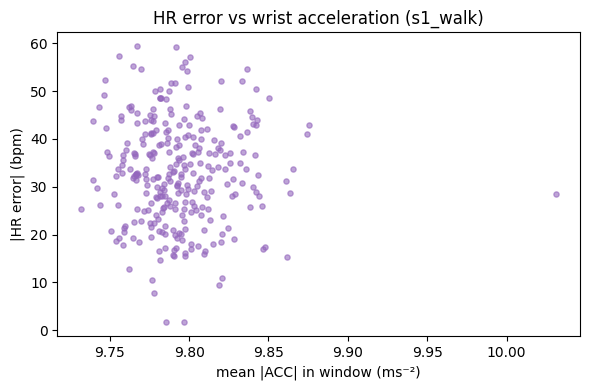

|HR error| — low-motion half: 33.1 bpm, high-motion half: 32.8 bpm


In [6]:
err = np.abs(hr_est - hr_ref)
acc_win = np.full(len(t_win), np.nan)
for k, t0 in enumerate(t_win):
    seg = acc_mag[int(t0*fs): int((t0+8.0)*fs)]
    if len(seg):
        acc_win[k] = seg.mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(acc_win[ok], err[ok], s=14, alpha=0.6, color="tab:purple")
ax.set_xlabel("mean |ACC| in window (ms⁻²)")
ax.set_ylabel("|HR error| (bpm)")
ax.set_title("HR error vs wrist acceleration (s1_walk)")
plt.tight_layout(); plt.show()

hi = acc_win[ok] > np.median(acc_win[ok])
print(f"|HR error| — low-motion half: {np.mean(err[ok][~hi]):.1f} bpm, "
      f"high-motion half: {np.mean(err[ok][hi]):.1f} bpm")

## 5. Findings

- **HR MAE ≈ 33 bpm on `s1_walk`** (bias +33 bpm — Lamina reads high),
  matching the Stage-2 per-record value exactly (`metrics_extra.csv`:
  `hr_bias_bpm = 32.96` for s1_walk). Across *all* walk records the Stage-2
  aggregate MAE is 15.9 bpm; `s1_walk` is the worst walk record.
- The error is motion-driven: the PPG morphology in §2 shows non-pulsatile
  swings that the peak detector locks onto (828 detected "beats" vs 563
  annotated heartbeats). On this record there is no clean subset to rescue —
  the median split by wrist acceleration leaves both halves at ≈33 bpm error,
  i.e. the motion contamination is pervasive rather than bursty.
- This record is hard even for the *ECG* pipeline: Stage-2 reports Lamina
  `ecg-peaks` F1 = 0.67 on the s1_walk chest ECG (973 detected vs 563
  annotated) and a 63.6 bpm annotation-vs-Lamina-ECG HR consistency gap —
  i.e. the motion corrupts both channels, and the annotation-derived
  reference itself implies a low mean HR (~57 bpm) for a walking subject.
- Honest bottom line: a non-motion-compensated PPG pipeline (no ACC-based
  rejection exists in the bridge ops) is not reliable on wrist PPG during
  walking. This is a validated limitation boundary, reported as-is; on clean
  signals the same pipeline reaches sub-bpm HR agreement (notebook 05, and
  the PPG group's BIDMC PPG-vs-ECG consistency checks).

*Environment*: bridge/lamina versions in the setup cell; data via `wfdb`
(pn_dir `wrist`), cached under `$HOME/data`.